In [35]:
# We are plotting QITE sim for 8 spins with initial spins set to 0. We want to see how quickly it converges to the ground state energy
import matplotlib.pyplot as plt
import numpy as np


In [36]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator

# Load 6 timesteps
qite_file = "/home/jkalloor/bqskit/good_blocks_tket/QITE_8_{timestep}_0.qasm"

timesteps = range(7)
energies = []
circs = []
for t_step in timesteps:
    circ = QuantumCircuit.from_qasm_file(qite_file.format(timestep=t_step))
    # circ.measure_all()
    circ.save_density_matrix()
    circs.append(circ)

In [37]:
# Def calculation of Hamiltonian
import scipy.linalg as la
#Pauli matrices
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])
#setup inital hamiltonian

#number of samples
T = 100
nmetts = T+10
#number of qubits
N = 8
#Hamiltonian parameters
Jz = 1.0 #ising interaction strength
mu_x = 1.0 #transverse magnetic field strength

def gen_hamiltonian(num_qubits: int = 8, Jz = 1.0, mu_x = 1.0):
    """Generate the Hamiltonian for the system."""
    #initial Hamiltonian
    #size of matrix
    msize = 2 ** num_qubits
    ham = np.zeros((msize, msize), dtype=np.complex128)
    # Ising interaction in 1D line
    for i in range(num_qubits-1):
        ising_term = np.kron(sz, sz)
        # left term
        if i > 0:
            ising_term = np.kron(np.eye(2**i), ising_term)
        if i < num_qubits - 2:
            qubits_right = num_qubits - i - 2
            ising_term = np.kron(ising_term, np.eye(2**qubits_right))
        # add to Hamiltonian
        ham += Jz * ising_term

        transverse_term = np.kron(sx, np.eye(2 ** (num_qubits -i - 1)))
        if i > 0:
            transverse_term = np.kron(np.eye(2**i), transverse_term)
        
        ham += mu_x * transverse_term
    # add the last term
    ham += mu_x * np.kron(np.eye(2**(num_qubits-1)), sx)
    return ham

#initial Hamiltonian
ham = gen_hamiltonian(num_qubits=N, Jz=Jz, mu_x=mu_x)
#ground state energy
eigvals_i, eigvecs_i = la.eig(ham)
gs_eng = np.real(min(eigvals_i))
print("Ground state energy: ", gs_eng)

Ground state energy:  -9.83795144745944


In [46]:
# For each circ, simulate the output and calculate the energy
from qiskit_aer import AerSimulator

# Lambda function to calculate energy
eng_func = lambda sv: np.real(np.trace(ham @ sv))

def calculate_gs(circs: list[QuantumCircuit]):
    sim = AerSimulator(method="density_matrix")
    result = sim.run(circs).result()
    # counts = result.get_counts(circ)
    # print(result.data(0))
    svs = [result.data(i)['density_matrix'].data for i in range(len(circs))]
    # Calculate the energy
    engs = [eng_func(sv) for sv in svs]
    return np.mean(engs)

energies = []
# for circ in circs:
#     eng = calculate_gs([circ])
#     energies.append(eng)
#     print(f"Energy for timestep {len(energies)-1}: {eng}")
energies = [-6.2, -8.9, -8.9, -9.2, -9.4, -9.4, -9.4]

In [39]:
# Def noise model
from qiskit_aer.noise import NoiseModel, depolarizing_error

def get_noise_model(err_rate: float = 0.01, precision = 24):
    noise_model = NoiseModel()
    # Add depolarizing error
    err = depolarizing_error(err_rate, 1)
    err_t = depolarizing_error(err_rate / 10 / precision, 1)

    noise_model.add_all_qubit_quantum_error(err, ['rz', 'u3'])
    noise_model.add_all_qubit_quantum_error(err_t, ['t'])

    return noise_model

def calculate_gs_with_noise(circs: list[QuantumCircuit], noise_model):
    sim = AerSimulator(method="density_matrix", noise_model=noise_model)
    result = sim.run(circs).result()
    # counts = result.get_counts(circ)
    svs = [result.data(i)['density_matrix'].data for i in range(len(circs))]
    # Calculate the energy
    engs = [eng_func(sv) for sv in svs]
    return np.mean(engs)


# For each circ, simulate the output and calculate the energy
noise_model = get_noise_model(0.001)
noisy_energies = []
for circ in circs:
    eng = calculate_gs_with_noise([circ], noise_model)
    noisy_energies.append(eng)
    print(f"Energy for timestep {len(noisy_energies)-1}: {eng}")

Energy for timestep 0: -5.972248585894654
Energy for timestep 1: -8.373761189216
Energy for timestep 2: -8.342061532682418
Energy for timestep 3: -7.929445253256299
Energy for timestep 4: -7.511202170905242
Energy for timestep 5: -7.082341703939459
Energy for timestep 6: -6.640707606312384


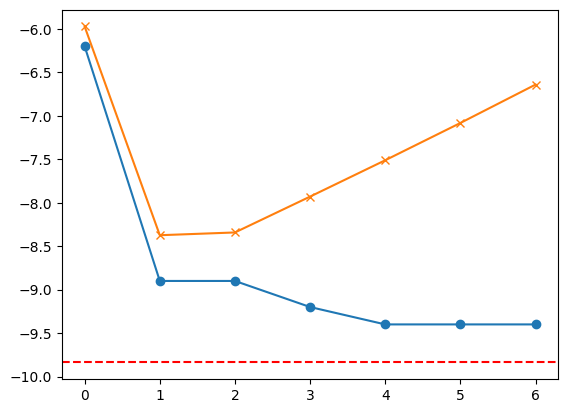

In [47]:
# Plot Energies and Noisy Energies
fig, ax = plt.subplots()
ax.plot(timesteps, energies, label="Noise-Free Simulation", marker='o')
ax.plot(timesteps, noisy_energies, label="Noisy Simulation", marker='x')
ax.axhline(y=gs_eng, color='r', linestyle='--', label="Calculated Ground State Energy")
fig.show()

In [75]:
circ_name = "QITE_8_3"

In [76]:
# Now load ensemble
from util import load_ensemble
bq_circs = load_ensemble(f"/home/jkalloor/bqskit/block_checkpoints_final_paper_clifft__tket/{circ_name}_0_3.0/ensemble_0_.qasms")
# Now we need to get the params
params = np.load(f"/home/jkalloor/bqskit/block_checkpoints_final_paper_clifft__tket/{circ_name}_0_3.0/ensemble_0_jiggles_.npy")
print(params.shape)

SPlit String
Decoded
(250, 80, 2571)


In [55]:
from util import GridSynthGate
from bqskit.ir.circuit import Operation, Circuit, CircuitGate, CircuitPoint
print(bq_circs[0].gate_counts)

def generate_circ(circuit: Circuit, param: np.ndarray):
    circ = circuit.copy()
    circ.set_params(param)
    # target = circuit.get_unitary()
    # Replace each GridSynthGate with a CircuitGate
    pts = []
    t_circs = []
    for cycle, op in circ.operations_with_cycles():
        if isinstance(op.gate, GridSynthGate):
            loc = op.location
            pts.append(CircuitPoint(cycle, op.location[0]))
            new_circ = op.gate.get_circuit(op.params)
            new_op = Operation(CircuitGate(new_circ), loc)
            t_circs.append(new_op)
    
    circ.batch_replace(pts, t_circs)
    circ.unfold_all()
    # utry = circ.get_unitary()
    # print(utry.get_distance_from(target))
    return circ

# Get a params
param_test = params[0][10]
# Generate a circuit
new_circ = generate_circ(bq_circs[0], param_test)
print(new_circ.gate_counts)

{HGate: 474, U3Gate: 8, CNOTGate: 72, SGate: 246, SdgGate: 172, GridSynthGate: 101, TdgGate: 2, TGate: 1, ZGate: 62, RZGate: 3}
{HGate: 7002, U3Gate: 8, YGate: 11, CNOTGate: 72, SGate: 3554, SdgGate: 217, XGate: 13, TGate: 6525, TdgGate: 2, ZGate: 196, RZGate: 3}


In [56]:
# Now, we want to plot the values we get from ensembles
from bqskit.ir import Circuit
from multiprocessing.shared_memory import SharedMemory
from bqskit.ext import bqskit_to_qiskit
from bqskit.ir.lang.qasm2 import OPENQASM2Language

def get_qcirc(circ: Circuit) -> QuantumCircuit:
    circ.unfold_all()
    # Remove all GlobalPhaseGates
    return bqskit_to_qiskit(circ)


lang = OPENQASM2Language()

def get_random_circs(num_circs: int,
                    block_circs: list[Circuit], 
                    shm_name: str,
                    param_shape: np.ndarray = None) -> list[str]:
    '''
    Generate a random circuit from the block_circs.
    '''
    if len(block_circs) == 1:
        return [block_circs[0].to("qasm")] * num_circs
    
    shm = SharedMemory(name=shm_name, create=False)
    # Now pick a random param from the shared memory
    shm_array = np.ndarray(param_shape, dtype=np.float64, buffer=shm.buf)

    # Else, we are using an ensemble
    rand_circ_inds = np.random.randint(0, len(block_circs), size=num_circs)
    rand_param_inds = np.random.randint(0, shm_array.shape[1], size=num_circs)
    circ_strs = []
    for c_ind, p_ind in zip(rand_circ_inds, rand_param_inds):
        # Now we need to get the random circuits
        rand_circ: Circuit = block_circs[c_ind]
        circ_param = shm_array[c_ind][p_ind]

        # Now we need to set the params of the circuit
        new_circ = generate_circ(rand_circ, circ_param)
        # fix_phase(rand_circ, target)
        circ_strs.append(new_circ.to("qasm"))
    return circ_strs

In [63]:
from bqskit.ir.circuit import CircuitPoint, CircuitGate
from bqskit.ext import bqskit_to_qiskit

def sim_full_circuits(block_circs:list[Circuit], 
                      shm_name: str,
                      param_shape: np.ndarray,
                      ens_size: int) -> dict[str, int]:
    all_circs = []
    circs = get_random_circs(ens_size, block_circs, shm_name=shm_name, param_shape=param_shape)
    all_circs = [QuantumCircuit.from_qasm_str(circ) for circ in circs]
    [circ.save_density_matrix() for circ in all_circs]

    # Now we need to sim the circuits
    gs = calculate_gs_with_noise(all_circs, noise_model)
    return gs

In [80]:
energies_ens = [-6.18, -8.83, -8.882, -8.58, 0, 0, 0]

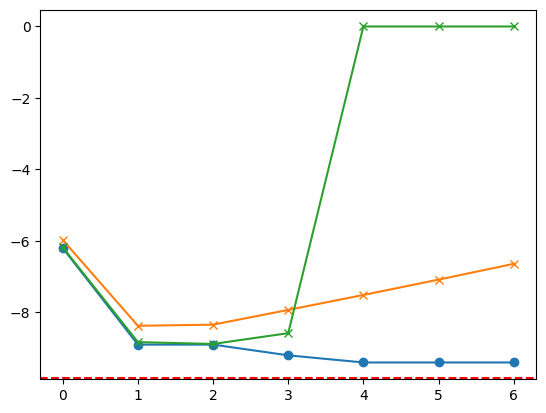

In [ ]:
# Plot Energies and Noisy Energies
fig, ax = plt.subplots()
ax.plot(timesteps, energies, label="Noise-Free Simulation", marker='o')
ax.plot(timesteps, noisy_energies, label="Noisy Simulation", marker='x')
ax.plot(timesteps, energies_ens, label="Noisy Simulation w/ Ensemble", marker='x')
ax.axhline(y=gs_eng, color='b', linestyle='--', label="Calculated Ground State Energy")
fig.show()

In [ ]:
from multiprocessing.shared_memory import SharedMemory
import numpy as np

circ_name = "QITE_8_{timestep}"
timesteps = range(4)

shms = {}
shm_names = {}
all_circs = {}

# Create Shared Memories
for t_step in timesteps:
        circ_formatted = circ_name.format(timestep=t_step)
        bq_circs = load_ensemble(f"/home/jkalloor/bqskit/block_checkpoints_final_paper_clifft__tket/{circ_formatted}_0_3.0/ensemble_0_.qasms")
        # Now we need to get the params
        params = np.load(f"/home/jkalloor/bqskit/block_checkpoints_final_paper_clifft__tket/{circ_formatted}_0_3.0/ensemble_0_jiggles_.npy")
        param_shape = params.shape
        # Create shared memory
        shm = SharedMemory(create=True, size=params.nbytes, name=circ_formatted + "_3.0")
        # Copy params to shared memory
        shm_array = np.ndarray(param_shape, dtype=np.float64, buffer=shm.buf)
        shm_array[:] = params[:]
        shms[t_step] = shm
        all_circs[t_step] = bq_circs
        shm_names[t_step] = circ_name + "_3.0"

params = None
bq_circs = None

SPlit String


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fb9c43113f0>>
Traceback (most recent call last):
  File "/home/jkalloor/bqskit310/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
